## Loading kaggle dataset & Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/bone-break-classification-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bone-break-classification-image-dataset' dataset.
Path to dataset files: /kaggle/input/bone-break-classification-image-dataset


In [2]:
import shutil
from pathlib import Path

dest = Path("./data/bone-break")  # your project path
dest.mkdir(parents=True, exist_ok=True)
for item in Path(path).iterdir():
    tgt = dest / item.name
    if item.is_dir():
        shutil.copytree(item, tgt, dirs_exist_ok=True)
    else:
        shutil.copy2(item, tgt)
print("Copied to:", dest)

Copied to: data/bone-break


In [3]:
!pwd

/content


In [4]:
from pathlib import Path
import json

# === Point this to the folder that CONTAINS all class folders ===
CWD = Path.cwd()  # '/content' in Colab
ROOT = CWD / "data" / "bone-break" / "Bone Break Classification" / "Bone Break Classification"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

def has_images(p: Path) -> bool:
    if not p.exists() or not p.is_dir():
        return False
    for q in p.rglob("*"):
        if q.is_file() and q.suffix.lower() in IMG_EXTS:
            return True
    return False

def derive_class_dirs(root: Path):
    """
    Return a sorted list of (class_name, class_dir) pairs.
    class_dir is the top-level folder representing the class.
    """
    class_pairs = []
    for child in sorted([d for d in root.iterdir() if d.is_dir()], key=lambda x: x.name.lower()):
        # Case 1: images are directly inside the child directory
        if has_images(child):
            class_pairs.append((child.name, child))
            continue

        # Case 2: images live under a Train/train folder inside the child
        train_dir = None
        for name in ("Train", "train"):
            cand = child / name
            if cand.is_dir() and has_images(cand):
                train_dir = cand
                break
        if train_dir is not None:
            class_pairs.append((child.name, child))

    # sanity check
    if not class_pairs:
        raise RuntimeError(f"No class folders with images found under: {root.resolve()}")

    return class_pairs

# ---- Run & summarize ----
class_dirs = derive_class_dirs(ROOT)
class_names = [name for name, _ in class_dirs]
class_to_idx = {name: i for i, name in enumerate(class_names)}

print("Discovered classes:")
for i, name in enumerate(class_names):
    print(f"[{i}] {name}")

# Optional: save mapping for later use
OUT = ROOT / "class_to_idx.json"
with OUT.open("w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"\nSaved class_to_idx to: {OUT}")

classes = sorted(class_names)

Discovered classes:
[0] Avulsion fracture
[1] Comminuted fracture
[2] Fracture Dislocation
[3] Greenstick fracture
[4] Hairline Fracture
[5] Impacted fracture
[6] Longitudinal fracture
[7] Oblique fracture
[8] Pathological fracture
[9] Spiral Fracture

Saved class_to_idx to: /content/data/bone-break/Bone Break Classification/Bone Break Classification/class_to_idx.json


Check runtime and GPU

In [5]:
!nvidia-smi -L || true
import torch, sys, os, pathlib, random
print("Torch:", torch.__version__, "CUDA:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

GPU 0: Tesla T4 (UUID: GPU-844f0dea-5631-7264-c170-5a5b46270f6f)
Torch: 2.9.0+cu126 CUDA: True


Install required packages

In [6]:
# core
!pip -q install --upgrade pip
!pip -q install legrad_torch open_clip_torch timm kagglehub pillow matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.2 MB/s eta 0:00:00


## Supervised Finetuning ViT with LeGrad

In [7]:
# === Finetune ViT with A/B/C + (1)(2)(3), then show LeGrad on the first Test image per class ===
# !pip install -q transformers timm pillow torchvision

import os, math, random
from pathlib import Path
from typing import List, Tuple, Dict

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms as T
from transformers import AutoImageProcessor, AutoModelForImageClassification, get_cosine_schedule_with_warmup

# ----------------------------
# Config
# ----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
ROOT = Path("/content/data/bone-break/Bone Break Classification/Bone Break Classification")
OUT_DIR = Path("/content/legrad_vit_first_per_class_finetuned")
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = "google/vit-base-patch16-224"
EPOCHS = 10
BATCH_SIZE = 16
# (1) Higher LR for head; lower LR for backbone (set below in param groups)
LR_HEAD = 2e-3
LR_BACKBONE = 1e-5
WEIGHT_DECAY = 0.05
LABEL_SMOOTH = 0.1
IMAGE_SIZE = 448
ALPHA = 0.35
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}
use_amp = (device == "cuda")

# ----------------------------
# Discover classes and split folders
# ----------------------------
def list_class_dirs(root: Path) -> List[Path]:
    return sorted([d for d in root.iterdir() if d.is_dir()], key=lambda p: p.name.lower())

def first_existing(*paths: Path) -> Path | None:
    for p in paths:
        if p is not None and p.exists():
            return p
    return None

class_dirs = list_class_dirs(ROOT)
classes = [d.name for d in class_dirs]
num_labels = len(classes)
label2id = {c:i for i,c in enumerate(classes)}
id2label = {i:c for c,i in label2id.items()}
print(f"Detected {num_labels} classes:", classes)

# ----------------------------
# Build Train/Test file lists from each class directory
# ----------------------------
def iter_images(d: Path) -> List[Path]:
    return [p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS]

train_files, test_files = [], []
for cdir in class_dirs:
    train_dir = first_existing(cdir / "Train", cdir / "train")
    test_dir  = first_existing(cdir / "Test",  cdir / "test", cdir)  # fallback: top-level if no Test/

    if train_dir:
        train_files += [(p, label2id[cdir.name]) for p in iter_images(train_dir)]
    if test_dir:
        test_files  += [(p,  label2id[cdir.name]) for p in iter_images(test_dir)]

print(f"Train images: {len(train_files)} | Test images: {len(test_files)}")
if len(train_files) == 0:
    raise RuntimeError("No training images found under any */Train or */train subfolder.")

# ----------------------------
# A) Stratified Train/Val split (e.g., 90/10)
# ----------------------------
from collections import defaultdict
by_cls = defaultdict(list)
for p, y in train_files:
    by_cls[y].append((p, y))

train_split, val_split = [], []
for y, items in by_cls.items():
    items = sorted(items, key=lambda z: z[0].as_posix().lower())
    k = max(1, int(0.1 * len(items)))  # 10% to val
    val_split.extend(items[:k])
    train_split.extend(items[k:])

print(f"Split -> train: {len(train_split)}, val: {len(val_split)}, test: {len(test_files)}")

# (3) Class weights (inverse frequency)
import numpy as np
# After you build train_split
import numpy as np
train_labels = [y for _, y in train_split]
counts = np.bincount(train_labels, minlength=num_labels)
class_weights = (counts.max() / np.maximum(counts, 1)).astype(np.float32)
class_weights_t = torch.tensor(class_weights, device=device)

# Focal loss (multiclass) with class weights
def focal_loss(logits, targets, gamma=1.5, alpha=None, label_smoothing=0.0):
    # logits: [B,C], targets: [B]
    ce = F.cross_entropy(logits, targets, weight=alpha, reduction="none",
                         label_smoothing=label_smoothing)
    # p_t = softmax prob at true class
    with torch.no_grad():
        pt = torch.softmax(logits, dim=-1).gather(1, targets.unsqueeze(1)).squeeze(1).clamp_(1e-6, 1.0)
    loss = ((1 - pt) ** gamma) * ce
    return loss.mean()

# ----------------------------
# Processor + B) Augmentations
# ----------------------------
processor = AutoImageProcessor.from_pretrained(MODEL_ID, use_fast=True)
mean = getattr(processor, "image_mean", [0.5, 0.5, 0.5])
std  = getattr(processor, "image_std",  [0.5, 0.5, 0.5])

TRAIN_SIZE = 224  # <— bump training/eval size; ViT pos-embed will interpolate
from torchvision import transforms as T

train_tfms = T.Compose([
    T.Resize(int(TRAIN_SIZE * 1.10)),
    T.RandomResizedCrop(TRAIN_SIZE, scale=(0.75, 1.0), ratio=(0.98, 1.02)),  # gentle geometry
    # T.RandomHorizontalFlip(p=0.3),  # enable only if laterality is not informative
    T.RandomRotation(degrees=5),
    # MEDICAL-FRIENDLY INTENSITY AUGS:
    T.RandomAutocontrast(p=0.3),
    T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.3),
    T.RandomEqualize(p=0.2),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

val_tfms = T.Compose([
    T.Resize(int(TRAIN_SIZE * 1.10)),
    T.CenterCrop(TRAIN_SIZE),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])


class ImgDataset(Dataset):
    def __init__(self, pairs: List[Tuple[Path,int]], transform):
        self.pairs, self.transform = pairs, transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self, i):
        path, y = self.pairs[i]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        return x, y, str(path)

def collate(batch):
    xs, ys, paths = zip(*batch)
    xs = torch.stack(xs, dim=0)
    ys = torch.tensor(ys, dtype=torch.long)
    return xs, ys, paths

train_loader = DataLoader(
    ImgDataset(train_split, train_tfms),
    batch_size=BATCH_SIZE,
    shuffle=True,               # or sampler=sampler (and shuffle=False)
    num_workers=2,
    pin_memory=use_amp,
    collate_fn=collate
)
val_loader   = DataLoader(ImgDataset(val_split,   val_tfms),   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=2, pin_memory=use_amp, collate_fn=collate)
test_loader  = DataLoader(ImgDataset(test_files,  val_tfms),   batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=2, pin_memory=use_amp, collate_fn=collate)

# ----------------------------
# Model
# ----------------------------
from transformers import get_cosine_schedule_with_warmup

model = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=num_labels, id2label=id2label, label2id=label2id,
    output_attentions=True, ignore_mismatched_sizes=True,
).to(device)

# Build layer-wise parameter groups (last layers get higher LR)
def build_param_groups_llrd(model,
                            base_lr_backbone=1e-4,
                            lr_head=2e-3,
                            weight_decay=0.05,
                            layer_decay=0.75):
    """
    Build disjoint param groups:
      - classifier head (lr_head)
      - vit.encoder.layer.0..11 with layer-wise lr decay
      - vit.embeddings + global vit.layernorm (smallest lr)
      - (optional) leftovers group if anything remains
    """
    groups = []
    used = set()

    def add_group(named_params, lr):
        # ensure uniqueness
        params = []
        for n, p in named_params:
            if p.requires_grad and id(p) not in used:
                params.append(p)
                used.add(id(p))
        if params:
            groups.append({"params": params, "lr": lr, "weight_decay": weight_decay})

    # 1) Head
    head_named = [(n, p) for n, p in model.named_parameters() if n.startswith("classifier")]
    add_group(head_named, lr_head)

    # 2) Encoder blocks (0..11), smaller lr for early layers, larger for later
    for i in range(12):
        prefix = f"vit.encoder.layer.{i}"
        layer_named = [(n, p) for n, p in model.named_parameters() if n.startswith(prefix)]
        lr_i = base_lr_backbone * (layer_decay ** (11 - i))
        add_group(layer_named, lr_i)

    # 3) Embeddings + global layernorm
    embed_named = [(n, p) for n, p in model.named_parameters()
                   if n.startswith("vit.embeddings") or n.startswith("vit.layernorm")]
    add_group(embed_named, base_lr_backbone * (layer_decay ** 12))

    # 4) (Optional) any leftovers, just in case (very conservative lr)
    leftovers = [(n, p) for n, p in model.named_parameters() if p.requires_grad and id(p) not in used]
    if leftovers:
        # You can print to see what's left: print([n for n,_ in leftovers])
        add_group(leftovers, base_lr_backbone * (layer_decay ** 12))

    # Sanity: no dupes
    assert len(used) == len({id(p) for _, p in model.named_parameters() if p.requires_grad}), \
        "Some trainable params were not grouped or duplicates slipped in."
    return groups

optimizer = torch.optim.AdamW(
    build_param_groups_llrd(
        model,
        base_lr_backbone=1e-4,
        lr_head=2e-3,
        weight_decay=WEIGHT_DECAY,
        layer_decay=0.75,
    )
)

num_train_steps = EPOCHS * len(train_loader)
sched = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(10, int(0.02 * max(1, num_train_steps))),  # very short warmup on small data
    num_training_steps=max(1, num_train_steps),
)
scaler = torch.amp.GradScaler(enabled=use_amp)

# (2) Gradual unfreeze: at epoch 2, unfreeze last 4 blocks + layer norms with small LR
def unfreeze_last_blocks():
    to_unfreeze = []
    last_blocks = [f"vit.encoder.layer.{i}" for i in [8, 9, 10, 11]]
    for n, p in model.named_parameters():
        if any(n.startswith(b) for b in last_blocks) or n.startswith("vit.layernorm"):
            if not p.requires_grad:
                p.requires_grad = True
                to_unfreeze.append(p)
    if to_unfreeze:
        optimizer.add_param_group({"params": to_unfreeze, "lr": LR_BACKBONE, "weight_decay": WEIGHT_DECAY})
        print(f"Unfroze {len(to_unfreeze)} backbone params with lr={LR_BACKBONE:g}")

def run_epoch(loader, train: bool):
    model.train(mode=train)
    total=correct=0; loss_sum=0.0
    for x,y,_ in loader:
        x,y = x.to(device, non_blocking=use_amp), y.to(device, non_blocking=use_amp)
        if train: optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            out = model(pixel_values=x, labels=None, output_attentions=False)
            logits = out.logits
            loss = focal_loss(logits, y, gamma=1.5, alpha=class_weights_t, label_smoothing=0.05)
        if train:
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update(); sched.step()
        pred = logits.argmax(-1)
        correct += (pred == y).sum().item()
        total += y.numel()
        loss_sum += float(loss) * y.numel()
    return loss_sum / max(total,1), correct / max(total,1)

best_val = -1.0; best_state = None
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} acc={tr_acc:.3f} | val_loss={vl_loss:.4f} acc={vl_acc:.3f}")
    if vl_acc > best_val:
        best_val = vl_acc
        best_state = {k: v.detach().cpu() for k,v in model.state_dict().items()}

if best_state: model.load_state_dict(best_state, strict=False)
te_loss, te_acc = run_epoch(test_loader, train=False)
print(f"[Final] test_loss={te_loss:.4f} acc={te_acc:.3f}")

# ===== LeGrad (unchanged) =====
model.eval()
ID2LABEL = model.config.id2label

def first_image_in_dir(d: Path) -> Path | None:
    imgs = sorted([p for p in d.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS],
                  key=lambda p: p.as_posix().lower())
    return imgs[0] if imgs else None

def list_first_images_per_class(root: Path) -> Dict[str, Path]:
    out = {}
    for cdir in class_dirs:
        tdir = first_existing(cdir / "Test", cdir / "test", cdir)
        img = first_image_in_dir(tdir) if tdir else None
        if img is not None:
            out[cdir.name] = img
    return out

per_class = list_first_images_per_class(ROOT)
print(f"Classes with a first test image: {len(per_class)}")

def compute_legrad_vit(image_pil: Image.Image, target_index: int | None = None, image_size: int = IMAGE_SIZE):
    img_resized = image_pil.resize((image_size, image_size), Image.BILINEAR)
    vis_inputs = processor(images=img_resized, return_tensors="pt")
    pixel_values = vis_inputs["pixel_values"].to(device)
    pixel_values.requires_grad_(True)

    out = model(pixel_values=pixel_values, output_attentions=True)
    logits = out.logits
    if target_index is None:
        target_index = int(logits.argmax(dim=-1).item())

    for a in out.attentions: a.retain_grad()
    loss = logits[0, target_index]
    model.zero_grad(set_to_none=True); loss.backward(retain_graph=False)

    grads_per_layer = []
    for a in out.attentions:
        g = a.grad
        if g is None: continue
        g = F.relu(g).mean(dim=1)    # [1, T, T]
        grads_per_layer.append(g[0]) # [T, T]
    if not grads_per_layer:
        raise RuntimeError("No attention gradients captured.")
    G = torch.stack(grads_per_layer, dim=0).sum(dim=0)  # [T,T]
    G = G[1:, 1:]                                       # drop [CLS]
    patch_scores = F.relu(G.sum(dim=0))
    patch_scores = patch_scores / (patch_scores.max() + 1e-8)

    side = int(np.sqrt(patch_scores.numel()))
    heat = patch_scores.reshape(side, side).detach().cpu().numpy().astype(np.float32)

    heat_img = Image.fromarray((heat * 255).astype(np.uint8)).resize((image_size, image_size), Image.BILINEAR)
    heat = np.array(heat_img, dtype=np.float32) / 255.0
    return heat, target_index

def save_overlay(pil_img: Image.Image, heat: np.ndarray, out_path: Path, alpha: float = ALPHA):
    W, H = pil_img.size
    hm = Image.fromarray((heat * 255).astype(np.uint8)).resize((W, H), Image.BILINEAR)
    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.imshow(hm, cmap="jet", alpha=alpha)
    plt.axis("off"); plt.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_path, dpi=150, bbox_inches="tight"); plt.close()

# Run LeGrad on first test image per class
outputs: List[Tuple[Path, str]] = []
for cls_name, img_path in per_class.items():
    raw = Image.open(img_path).convert("RGB")
    heat, cls_idx = compute_legrad_vit(raw)
    pred_label = ID2LABEL.get(cls_idx, f"class_{cls_idx}")
    out_png = OUT_DIR / f"{Path(img_path).stem}__{pred_label.replace(' ', '_')}.png"
    save_overlay(raw, heat, out_png)
    outputs.append((out_png, cls_name, pred_label))

print(f"Saved {len(outputs)} overlays to: {OUT_DIR}")

Detected 10 classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Train images: 989 | Test images: 140
Split -> train: 896, val: 93, test: 140


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-33826721.py:288: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss_sum += float(loss) * y.numel()


Epoch 01 | train_loss=2.6771 acc=0.171 | val_loss=2.5820 acc=0.151
Epoch 02 | train_loss=1.9468 acc=0.423 | val_loss=2.4440 acc=0.290
Epoch 03 | train_loss=1.3750 acc=0.583 | val_loss=2.5294 acc=0.280
Epoch 04 | train_loss=0.8951 acc=0.719 | val_loss=2.3664 acc=0.355
Epoch 05 | train_loss=0.5249 acc=0.852 | val_loss=2.4094 acc=0.344
Epoch 06 | train_loss=0.4020 acc=0.886 | val_loss=2.3712 acc=0.344
Epoch 07 | train_loss=0.2822 acc=0.936 | val_loss=2.4056 acc=0.355
Epoch 08 | train_loss=0.2584 acc=0.946 | val_loss=2.3992 acc=0.387
Epoch 09 | train_loss=0.2585 acc=0.940 | val_loss=2.3841 acc=0.366
Epoch 10 | train_loss=0.2404 acc=0.951 | val_loss=2.3866 acc=0.366
[Final] test_loss=2.2408 acc=0.457
Classes with a first test image: 10
Saved 10 overlays to: /content/legrad_vit_first_per_class_finetuned


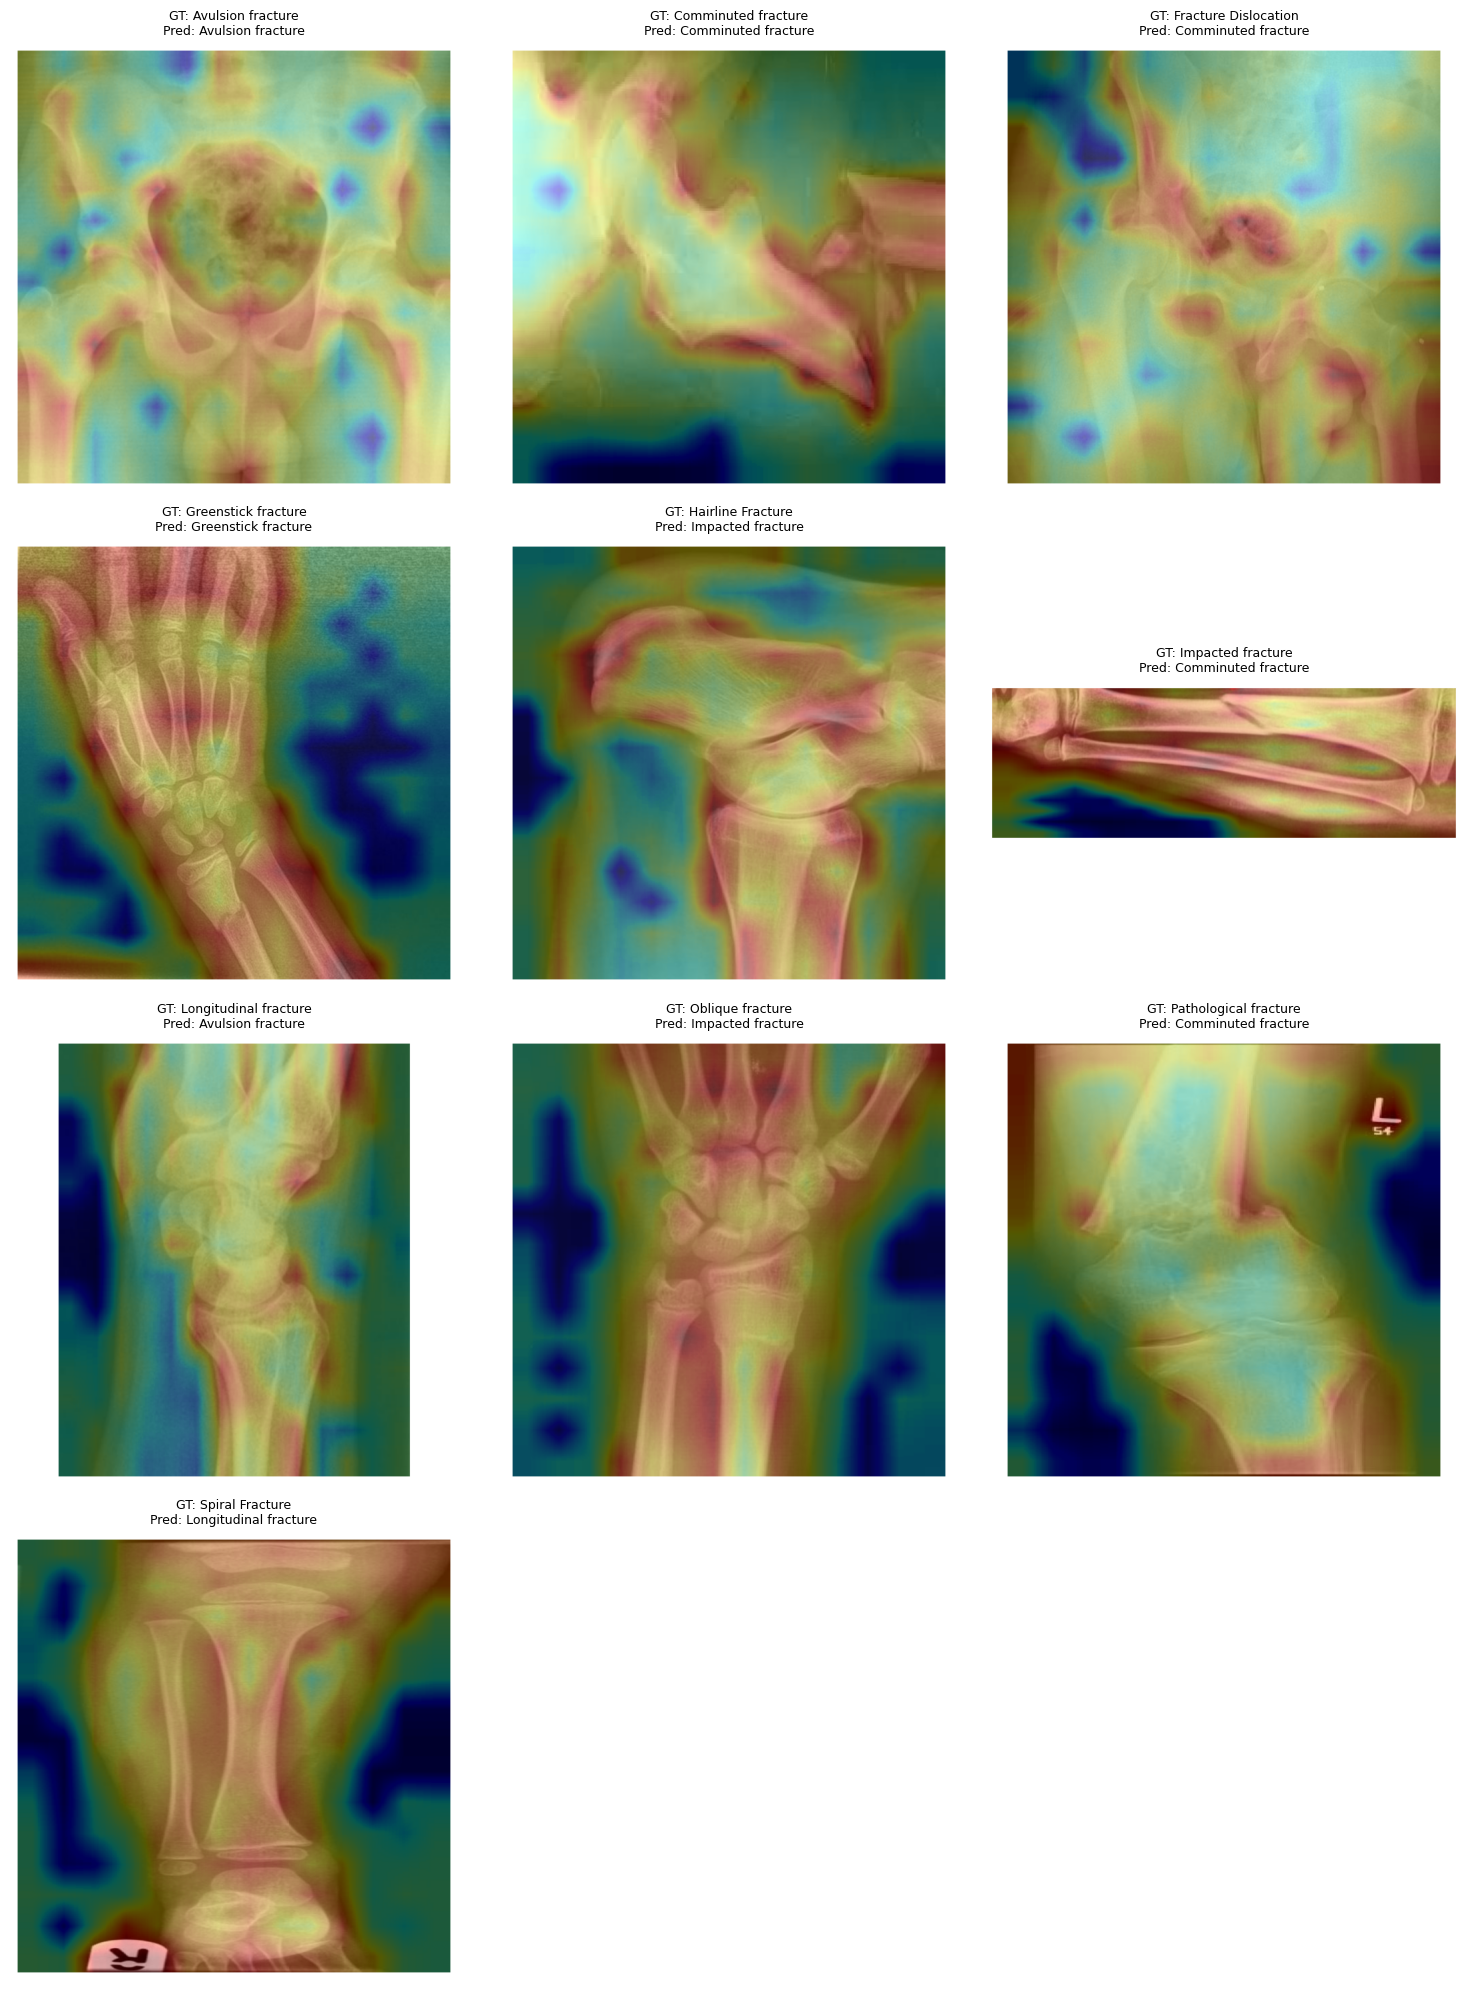

In [ ]:
# Display grid
cols = 3
rows = math.ceil(len(outputs) / cols) if outputs else 1
plt.figure(figsize=(5*cols, 5*rows))
for i, (op, true_lbl, pred_lbl) in enumerate(outputs, start=1):
    ax = plt.subplot(rows, cols, i)
    ax.imshow(Image.open(op).convert("RGB"))
    ax.set_title(f"GT: {true_lbl}\nPred: {pred_lbl}", fontsize=9)
     # Show both actual and predicted
    ax.axis("off")
plt.tight_layout(); plt.show()

In [16]:
import math
import torch
import torch.nn.functional as F

class TokenGradExplainer:
    """
    Grad-CAM-style token gradient explainer for ViT / PH-Reg student:
    - Hooks each transformer block's output tokens.
    - Collects outputs + gradients.
    - Uses grad * activation over patch tokens, aggregated across layers,
      to produce a per-patch importance map.
    """

    def __init__(self, student_model, device, img_size=224, num_registers=0):
        self.model = student_model
        self.device = device
        self.img_size = img_size
        self.num_registers = num_registers

        # ---- Infer num_patches for different model types ----
        base = getattr(self.model, "vit", self.model)  # HF ViTForImageClassification has .vit

        if hasattr(base, "patch_embed") and hasattr(base.patch_embed, "num_patches"):
            # e.g. timm / custom ViT
            num_patches = base.patch_embed.num_patches
        elif hasattr(base, "embeddings") and hasattr(base.embeddings, "patch_embeddings"):
            # HuggingFace ViTModel / ViTForImageClassification
            num_patches = base.embeddings.patch_embeddings.num_patches
        elif hasattr(base, "config") and hasattr(base.config, "image_size") and hasattr(base.config, "patch_size"):
            # Fallback using config
            img_size_cfg = base.config.image_size
            patch_size = base.config.patch_size
            num_patches = (img_size_cfg // patch_size) ** 2
        else:
            raise RuntimeError("Could not infer num_patches for this model; please adapt TokenGradExplainer.")

        self.grid_size = int(math.sqrt(num_patches))
        assert self.grid_size * self.grid_size == num_patches, \
            f"num_patches={num_patches} is not a perfect square"

    # ---- helper: get list of transformer blocks depending on model type ----
    def _get_blocks(self):
        # PH-Reg wrapper or timm-style: model.vit.blocks or model.blocks
        if hasattr(self.model, "vit") and hasattr(self.model.vit, "blocks"):
            return list(self.model.vit.blocks)
        if hasattr(self.model, "blocks"):
            return list(self.model.blocks)

        # HuggingFace ViTModel: encoder.layer
        base = getattr(self.model, "vit", self.model)
        if hasattr(base, "encoder") and hasattr(base.encoder, "layer"):
            return list(base.encoder.layer)

        raise RuntimeError("Cannot find transformer blocks on this model; expected .vit.blocks, .blocks or .encoder.layer")

    def _register_hooks(self):
        self.block_outs = []
        self.block_grads = []
        self.handles = []

        def make_hook(idx):
            def hook(module, input, output):
                # output: tokens from this block, shape [B, T, D]
                self.block_outs.append(output)

                def grad_hook(grad):
                    self.block_grads.append(grad)

                output.register_hook(grad_hook)
            return hook

        for i, blk in enumerate(self._get_blocks()):
            h = blk.register_forward_hook(make_hook(i))
            self.handles.append(h)

    def _remove_hooks(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def generate(self, img, target_class=None):
        """
        img: tensor [1, 3, H, W] (normalized like training).
        target_class: int or None.
          - If None, uses the model's predicted class.
        Returns:
            heatmap: [H, W] tensor in [0, 1].
        """
        self.model.eval()
        img = img.to(self.device)

        # 1) Register hooks
        self._register_hooks()

        # 2) Forward + backward
        self.model.zero_grad(set_to_none=True)

        outputs = self.model(img)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs  # HF vs raw tensor

        if target_class is None:
            target_class = logits.argmax(dim=1)
        elif isinstance(target_class, int):
            target_class = torch.tensor([target_class], device=self.device)

        one_hot = torch.zeros_like(logits)
        one_hot[0, target_class.item()] = 1.0
        (logits * one_hot).sum().backward()

        # 3) Build per-layer patch importance maps
        assert len(self.block_outs) == len(self.block_grads), \
            "Mismatch in block_outs vs block_grads"

        per_layer_maps = []
        N = self.grid_size * self.grid_size  # number of patches

        for out, grad in zip(self.block_outs, self.block_grads):
            # out, grad: [B, T, D], T = 1 + N (+ K registers inside block)
            B, T, D = out.shape
            assert B == 1, "Explainer currently assumes batch_size=1"

            # Tokens layout:
            # - CLS at index 0
            # - N image patches at indices [1 .. 1+N-1]
            # (extra tokens like registers, if any, are at the end)
            patch_out  = out[:, 1:1+N, :]    # [1, N, D]
            patch_grad = grad[:, 1:1+N, :]   # [1, N, D]

            # Grad * activation, ReLU, average over hidden dim
            cam = (patch_out * patch_grad).clamp(min=0).mean(dim=-1)  # [1, N]
            per_layer_maps.append(cam.squeeze(0))  # [N]

        if not per_layer_maps:
            self._remove_hooks()
            raise RuntimeError("No block outputs were captured; hooks did not fire.")

        # 4) Aggregate across layers: [L, N] -> [N]
        token_importance = torch.stack(per_layer_maps, dim=0).mean(dim=0)  # [N]

        # Normalize over patches
        token_importance = token_importance - token_importance.min()
        if token_importance.max() > 0:
            token_importance = token_importance / token_importance.max()

        # 5) Reshape to patch grid + upsample to image resolution
        grid = token_importance.view(1, 1, self.grid_size, self.grid_size)  # [1,1,h,w]
        heatmap = F.interpolate(
            grid,
            size=(self.img_size, self.img_size),
            mode="bilinear",
            align_corners=False,
        ).squeeze(0).squeeze(0)  # [H, W]

        # Normalize again to [0, 1]
        heatmap = heatmap - heatmap.min()
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        # 6) Clean up
        self._remove_hooks()

        return heatmap.detach().cpu()

In [41]:
from pathlib import Path
from typing import List

def list_images_in_dir(
    dir_path: Path,
    exts=(".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
) -> List[Path]:
    """
    Return all image files in `dir_path` (non-recursive).
    """
    return sorted(
        p for p in dir_path.iterdir()
        if p.is_file() and p.suffix.lower() in exts
    )

CLASS = "Impacted fracture"

# Your Longitudinal fracture Test folder
TEST_DIR = Path(f"/content/data/bone-break/Bone Break Classification/Bone Break Classification/{CLASS}/Test")

longitudinal_imgs = list_images_in_dir(TEST_DIR)

print(len(longitudinal_imgs), "images found")
print(longitudinal_imgs[:5])  # peek first few

9 images found
[PosixPath('/content/data/bone-break/Bone Break Classification/Bone Break Classification/Impacted fracture/Test/0fd9c4957210d0c8324ccc00c39d243d_jpg.rf.7625244128c1f6a73965a0290b6e6c31.jpg'), PosixPath('/content/data/bone-break/Bone Break Classification/Bone Break Classification/Impacted fracture/Test/12891_2018_2170_Fig1_HTML_png.rf.2d45186e46a8dac72a42e99ecc1a957c.jpg'), PosixPath('/content/data/bone-break/Bone Break Classification/Bone Break Classification/Impacted fracture/Test/2021_04_07_19_24_6029_2021_04_07_Ulnar_Fracture_jpg.rf.731c2017d7a1d53d0eaf9ace647e8912.jpg'), PosixPath('/content/data/bone-break/Bone Break Classification/Bone Break Classification/Impacted fracture/Test/20980tn_jpg.rf.08df4572fdeb34428103e11296500c19.jpg'), PosixPath('/content/data/bone-break/Bone Break Classification/Bone Break Classification/Impacted fracture/Test/3-s2-0-B9781782424499000042-f04-05-9781782424499_jpg.rf.697fc1f3f837a4facd89b17281dc3843.jpg')]


True label: Impacted fracture, Predicted: 1


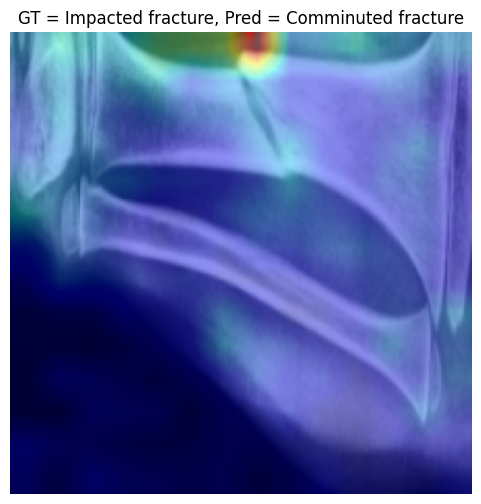

True label: Impacted fracture, Predicted: 5


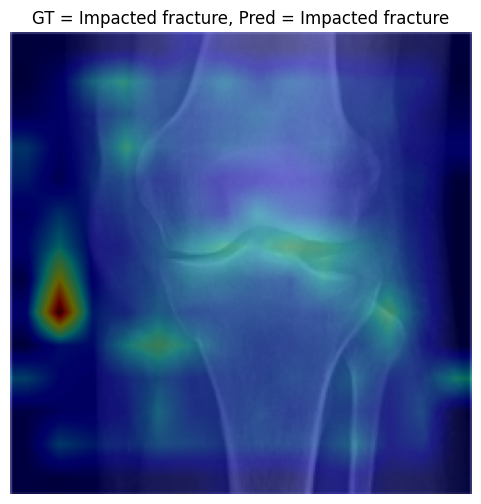

True label: Impacted fracture, Predicted: 6


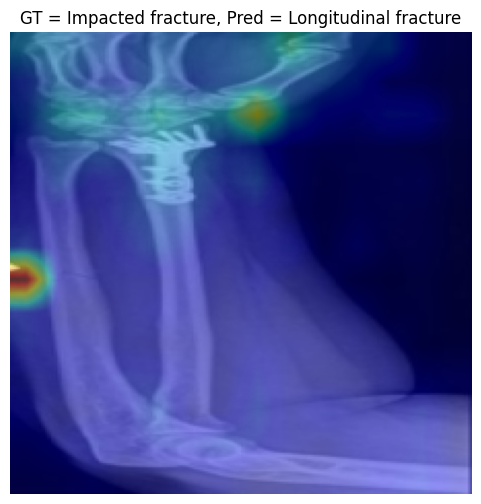

True label: Impacted fracture, Predicted: 5


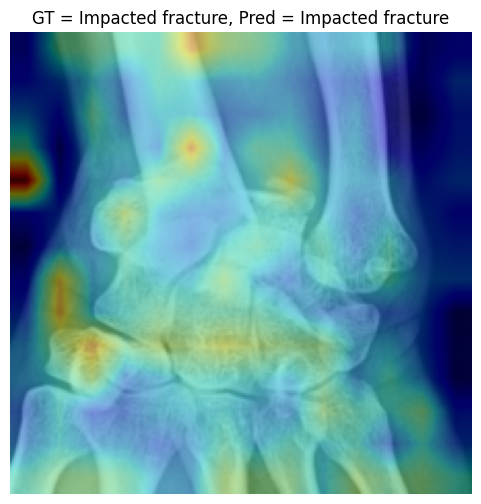

True label: Impacted fracture, Predicted: 8


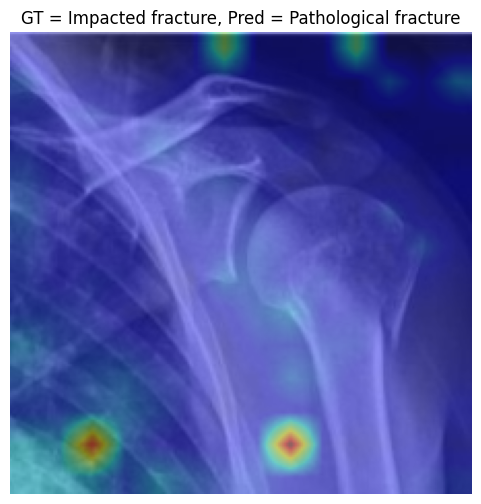

True label: Impacted fracture, Predicted: 8


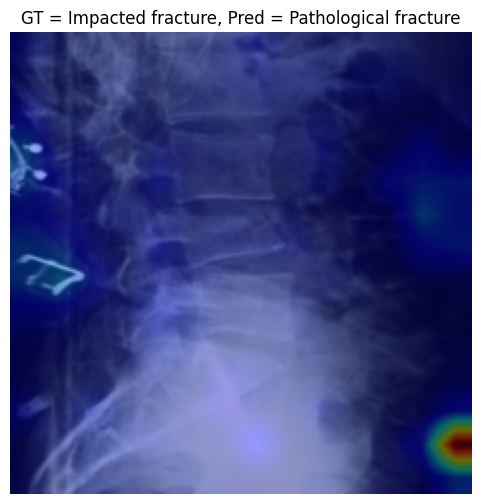

True label: Impacted fracture, Predicted: 7


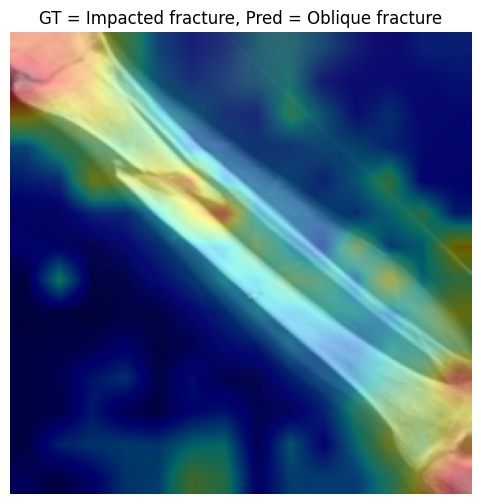

True label: Impacted fracture, Predicted: 2


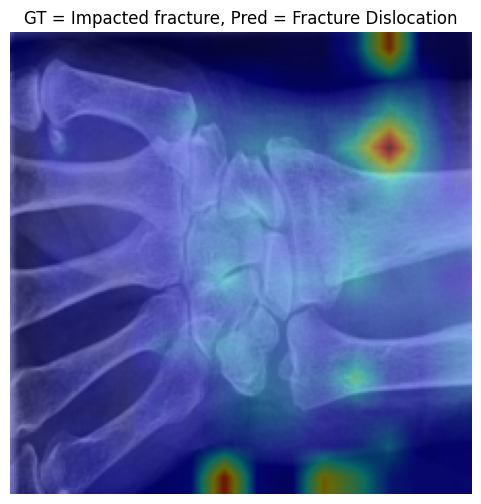

True label: Impacted fracture, Predicted: 5


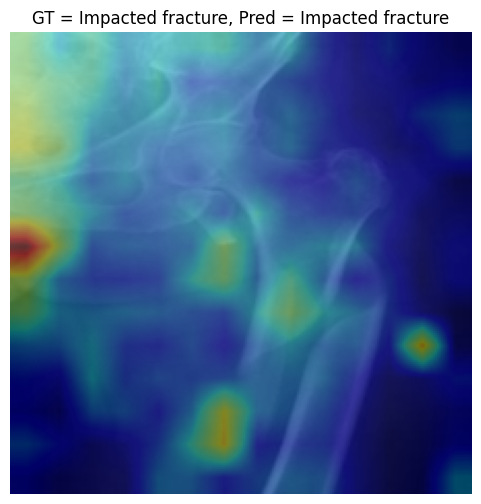

In [42]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5]),
])

explainer = TokenGradExplainer(model, device=device, img_size=224, num_registers=0)

cls_name = CLASS
for img_path in longitudinal_imgs:
    # 1) PIL image (same as LeGrad)
    img_pil = Image.open(img_path).convert("RGB")

    # 2) Preprocess to tensor batch (LeGrad used `processor`, here you use `transform`)
    img_tensor = transform(img_pil).unsqueeze(0).to(device)  # [1,3,H,W]

    # 3) Predicted class (you can keep this part similar)
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor).logits
    pred_class = logits.argmax(dim=1).item()
    print(f"True label: {cls_name}, Predicted: {pred_class}")

    # 4) TokenGrad heatmap (analogous to compute_legrad_vit)
    heatmap = explainer.generate(img_tensor, target_class=pred_class)  # [H,W]

    # 5) De-normalize for visualization
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std  = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    img_vis = img_tensor[0].detach().cpu() * std + mean
    img_vis = img_vis.clamp(0, 1).permute(1, 2, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(img_vis)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    plt.axis("off")
    plt.title(f"GT = {cls_name}, Pred = {id2label[pred_class]}")
    plt.show()

In [26]:
label2id

{'Avulsion fracture': 0,
 'Comminuted fracture': 1,
 'Fracture Dislocation': 2,
 'Greenstick fracture': 3,
 'Hairline Fracture': 4,
 'Impacted fracture': 5,
 'Longitudinal fracture': 6,
 'Oblique fracture': 7,
 'Pathological fracture': 8,
 'Spiral Fracture': 9}